# Projeto 3 — Interpolação e Regressão Polinomial
Este notebook implementa os conceitos da questão 1 para as questões 2 e 3 do Projeto 3 em Julia.
Ele mostra a matriz de avaliação em base canônica (Vandermonde), a base de Lagrange, e a matriz de regressão por mínimos quadrados.

## 1. Funções auxiliares
Definimos a matriz de Vandermonde para a base canônica e uma função para construir a matriz de avaliação na base de Lagrange.

In [11]:
using LinearAlgebra

function vandermonde(x::Vector{Float64}, d::Integer)
    m = length(x)
    V = zeros(Float64, m, d + 1)
    for i in 1:m, j in 1:d + 1
        V[i, j] = x[i]^(j - 1)
    end
    return V
end

function least_squares_matrix(A::AbstractMatrix{Float64})
    # A é a matriz de avaliação L_X em alguma base de P_d.
    # A solução dos mínimos quadrados seria p = R_X,d * b, onde R_X,d = pinv(A).
    return pinv(A)
end

function lagrange_basis(nodes::Vector{Float64})
    n = length(nodes)
    basis = Vector{Function}(undef, n)
    for i in 1:n
        xi = nodes[i]
        denom = prod(xi - nodes[j] for j in 1:n if j != i)
        basis[i] = x -> begin
            num = prod(x - nodes[j] for j in 1:n if j != i)
            return num / denom
        end
    end
    return basis
end

function lagrange_eval_matrix(X::Vector{Float64}, nodes::Vector{Float64})
    basis = lagrange_basis(nodes)
    m = length(X)
    k = length(nodes)
    M = zeros(Float64, m, k)
    for i in 1:m, j in 1:k
        M[i, j] = basis[j](X[i])
    end
    return M
end

lagrange_eval_matrix (generic function with 1 method)

## 2. Montando as matrizes de avaliação e regressão
Aqui simulamos um conjunto de pontos distintos `X` e construímos as matrizes `L_X` e `R_X,d` em duas bases diferentes.

In [12]:
X = collect(range(-1.0, 1.0, length = 200))
d = 10
A = vandermonde(X, d)
R = least_squares_matrix(A)
println("Matriz L_X em base canônica (Vandermonde): tamanho = ", size(A))
println("Matriz R_X,d em base canônica: tamanho = ", size(R))
println("cond(L_X) = ", cond(A))
println("cond(R_X,d) = ", cond(R))

Matriz L_X em base canônica (Vandermonde): tamanho = (200, 11)
Matriz R_X,d em base canônica: tamanho = (11, 200)
cond(L_X) = 2988.1042180993554
cond(R_X,d) = 2988.1042180994978


## 3. Base de Lagrange
Construímos a base de Lagrange usando os primeiros `d+1` pontos de `X`.

In [13]:
nodes = collect(range(-1.0, 1.0, length = d + 1))
A_lagr = lagrange_eval_matrix(X, nodes)
R_lagr = least_squares_matrix(A_lagr)
println("Matriz L_X em base de Lagrange: tamanho = ", size(A_lagr))
println("cond(L_X) em Lagrange = ", cond(A_lagr))
println("cond(R_X,d) em Lagrange = ", cond(R_lagr))

Matriz L_X em base de Lagrange: tamanho = (200, 11)
cond(L_X) em Lagrange = 34.412728885431044
cond(R_X,d) em Lagrange = 34.41272888543106


## 4. Teste com um vetor de dados
A melhor forma de ver o efeito do condicionamento é aplicar as matrizes a um vetor de observações.

In [14]:
b = sin.(2π .* X) .+ 0.1 .* randn(length(X))
p_mono = R * b
p_lagr = R_lagr * b
println("Erro residual usando base canônica: ", norm(A * p_mono - b))
println("Erro residual usando base de Lagrange: ", norm(A_lagr * p_lagr - b))

Erro residual usando base canônica: 1.3622909162951504
Erro residual usando base de Lagrange: 1.362290916295151


## 5. Interpretação e próximos passos
- `L_X` em base canônica é a matriz de Vandermonde.
- `R_X,d` é a pseudo-inversa de `L_X`, que representa a regressão de mínimos quadrados.
- A base de Lagrange muda a forma de `L_X`, e isso pode afetar o condicionamento.

### Para avançar
1. Varie `m` e `d` e veja como `cond(A)` e `cond(R)` mudam.
2. Compare o comportamento usando `X` equiespaçados e `X` de Chebyshev.
3. Adicione um gráfico com `Plots` para mostrar o crescimento do condicionamento com `d`.

# Questão 2
### (a)
Tome $q \in \mathcal{P}_d$ qualquer. Daí,


$$R_{X,d}(L_X(q)) = \arg\min_{p \in \mathcal{P}_d} ||L_X(p) - L_X(q)||_2^2$$

É fato que para $p = q \implies ||L_X(p) - L_X(q)||_2^2 = 0$. Para garantir que $R_{X,d}(L_X(q)) = q$, e que $q$ é o único que satisfaz $\arg\min_{p \in \mathcal{P}_d} ||L_X(p) - L_X(q)||_2^2 = 0$, verificamos que $L_X$ é injetora, ou seja, $L_X(p) = L_X(q) \implies p = q$.

Para tal, vamos mostrar que $\dim(\mathcal{N}(L_X)) = 0$. Suponha $p \in \mathcal{N}(L_X)$. Então $L_X(p) = (0, \dots, 0)$, ou seja, $p(x_i) = 0$ para todo $x_i \in X$.

Como $p$ tem grau no máximo $d$, $p$ deve possuir no máximo $d$ raízes. Mas $p(x) = 0$ para $m > d$ diferentes valores de $x$, logo, $p$ só pode ser o polinômio identicamente nulo. Ou seja, $\dim(\mathcal{N}(L_X)) = 0$ e $L_X$ é injetiva, como queríamos mostrar.


### (b)

Primeiramente, aproveitando os resultados da Questão 1, podemos expressar a transformação $L_X$ sobre $p \in \mathcal{P}_d$ na forma matricial como $L_X(p) = Vc$, onde $V$ é a matriz de Vandermonde de dimensões $m \times (d+1)$ dos pontos do conjunto $X$, e $c$ é o vetor com os coeficientes de $p$.

Desse modo, o problema de encontrar o polinômio $p$ equivale a encontrar os coeficientes $c$ que minimizam a expressão:
$$\arg\min_{c \in \mathbb{R}^{d+1}} ||Vc - b||_2^2$$

Note que:
$$||Vc-b||_2^2 = (Vc-b)^T(Vc-b) = c^T V^T V c - c^T V^T b - b^T V c + b^T b = c^T V^T V c - 2b^T V c + b^T b$$

Para encontrar o vetor $c$ que minimiza essa função, calculamos o gradiente em relação a $c$ e igualamos ao vetor nulo:
$$\nabla_c (c^T V^T V c - 2b^T V c + b^T b) = 2V^TVc - 2V^Tb = 0$$

Como $m \ge d+1$ e os pontos de $X$ são distintos, $V$ tem posto completo nas colunas, o que garante que $V^TV$ seja inversível. Isolando $c$:
$$V^TVc = V^Tb \implies c = (V^TV)^{-1}V^Tb$$

Assim, transformação $R_{X,d}$ mapeia o vetor $b$ para os coeficientes do polinômio essencialmente através da multiplicação matricial $(V^TV)^{-1}V^Tb$, logo vale a linearidade:

1. $R_{X,d}(b_1 + b_2) = (V^TV)^{-1}V(b_1 + b_2) = (V^TV)^{-1}Vb_1 + (V^TV)^{-1}Vb_2 = R_{X,d}(b_1) + R_{X,d}(b_2)$
2. $R_{X,d}(\alpha b) = (V^TV)^{-1}V(\alpha b) = \alpha((V^TV)^{-1}Vb) = \alpha R_{X,d}(b)$

Logo, concluímos que $R_{X,d}$ é uma transformação linear.

### (c)

Do item anterior, a matriz de $R_{X,d}$ na base canônica é a própria $(V^TV)^{-1}V^T$, onde $V$ é construída avaliando a base canônica $\{1, x, x^2, \dots, x^d\}$ nos pontos $x \in X$.

### (d)

### (d) Condicionamento de $L_X$ e $R_{X,d}$

Exploramos como o número de condicionamento das matrizes $L_X$ (Vandermonde) e $R_{X,d} = L_X^+$ se comporta ao variar $m$ e $d$.

**Observação teórica:** Para qualquer matriz $A$ de posto completo, $\\kappa(A^+) = \\kappa(A)$, pois os valores singulares de $A^+$ são os recíprocos dos de $A$. Logo, $L_X$ e $R_{X,d}$ têm sempre o **mesmo** número de condicionamento — confirmado experimentalmente no Plot 4 abaixo.

In [ ]:
using LinearAlgebra, Plots, Printf, LaTeXStrings
default(fontfamily="Computer Modern", titlefontsize=11,
        guidefontsize=10, legendfontsize=9, tickfontsize=8)

# ─── Plot 1: cond(L_X) base canonica x grau d (varios m) ──────────────────
# A Vandermonde e notoria por seu condicionamento que cresce com d.
# Fixamos m e varremos d para ver essa explosao.

d_vals = 2:2:20
m_vals = [20, 50, 100]

p1 = plot(title=L"\kappa(L_X) \textrm{ canonica vs grau } d",
          xlabel=L"d \textrm{ (grau)}", ylabel=L"\kappa \textrm{ (log}_{10}\textrm{)}",
          yscale=:log10, legend=:topleft, lw=2,
          markershape=:circle, ms=5, palette=:tab10)

for m in m_vals
    X = collect(range(-1.0, 1.0, length=m))
    kappa = [cond(vandermonde(X, d)) for d in d_vals]
    plot!(p1, collect(d_vals), kappa, label=L"m = %$m")
end

# ─── Plot 2: cond(L_X) base canonica x m (d fixo) ─────────────────────────
# Aumentar m com d fixo NAO explode o condicionamento:
# e o grau d que domina o crescimento, nao o numero de amostras.

d_fixed = [4, 8, 12]
m_range = 10:5:150

p2 = plot(title=L"\kappa(L_X) \textrm{ canonica vs } m \textrm{ (d fixo)}",
          xlabel=L"m \textrm{ (pontos)}", ylabel=L"\kappa \textrm{ (log}_{10}\textrm{)}",
          yscale=:log10, legend=:topright, lw=2,
          markershape=:circle, ms=4, palette=:Set2)

for d in d_fixed
    kappa = [cond(vandermonde(collect(range(-1.0, 1.0, length=m)), d)) for m in m_range]
    plot!(p2, collect(m_range), kappa, label=L"d = %$d")
end

# ─── Plot 3: base canonica vs base de Lagrange (m fixo, d variando) ────────
# Na base de Lagrange, a sub-matriz quadrada dos nos e a identidade (kappa=1).
# Com m > d+1 pontos extras o kappa sobe levemente, mas nada comparado a Vandermonde.

m_ref = 50
X_ref = collect(range(-1.0, 1.0, length=m_ref))

kappa_canon = [cond(vandermonde(X_ref, d)) for d in d_vals]
kappa_lagr  = [cond(lagrange_eval_matrix(X_ref,
               collect(range(-1.0, 1.0, length=d+1)))) for d in d_vals]

p3 = plot(title=L"\kappa(L_X)\textrm{: canonica vs Lagrange } (m=%$m_ref)",
          xlabel=L"d \textrm{ (grau)}", ylabel=L"\kappa \textrm{ (log}_{10}\textrm{)}",
          yscale=:log10, legend=:topleft, lw=2)
plot!(p3, collect(d_vals), kappa_canon, label=L"\textrm{base canonica}",
      color=:crimson,    markershape=:circle, ms=5)
plot!(p3, collect(d_vals), kappa_lagr,  label=L"\textrm{base de Lagrange}",
      color=:royalblue,  markershape=:square, ms=5)
hline!(p3, [1.0], ls=:dot, color=:gray, label=L"\kappa = 1", lw=1.5)

# ─── Plot 4: kappa(L_X) vs kappa(R_{X,d}) — confirmando kappa(A+) = kappa(A)
# Teorema: para A de posto completo, A+ = V*Sigma^{-1}*U' =>
# kappa(A+) = sigma_1/sigma_n = kappa(A). As curvas devem colapsar.

m_ref2 = 40
X_ref2 = collect(range(-1.0, 1.0, length=m_ref2))
d_check = 2:2:14

kappa_LX  = [cond(vandermonde(X_ref2, d))       for d in d_check]
kappa_RXd = [cond(pinv(vandermonde(X_ref2, d))) for d in d_check]

p4 = plot(title=L"\kappa(L_X) = \kappa(R_{X,d})\textrm{? } (m=%$m_ref2)",
          xlabel=L"d \textrm{ (grau)}", ylabel=L"\kappa \textrm{ (log}_{10}\textrm{)}",
          yscale=:log10, legend=:topleft, lw=2)
plot!(p4, collect(d_check), kappa_LX,  label=L"\kappa(L_X)",
      color=:darkorange, markershape=:circle,    ms=6, lw=2)
plot!(p4, collect(d_check), kappa_RXd, label=L"\kappa(R_{X,d})",
      color=:purple,     markershape=:utriangle, ms=6, lw=2, ls=:dash)

# ─── Painel 2x2 ────────────────────────────────────────────────────────────
fig = plot(p1, p2, p3, p4, layout=(2, 2), size=(950, 680), margin=5Plots.mm)
display(fig)

# ─── Tabela resumo ─────────────────────────────────────────────────────────
println("\n===  kappa(L_X) — base canonica  ===")
header = rpad("m \\ d", 8) * join(rpad.(string.(collect(d_vals)), 13))
println(header)
for m in [20, 50, 100]
    X = collect(range(-1.0, 1.0, length=m))
    row = [@sprintf("%.1e", cond(vandermonde(X, d))) for d in d_vals]
    println(rpad("m=$m", 8), join(rpad.(row, 13)))
end

println("\n===  kappa(L_X) — base de Lagrange  ===")
println(header)
for m in [20, 50, 100]
    X = collect(range(-1.0, 1.0, length=m))
    row = [@sprintf("%.1e", cond(lagrange_eval_matrix(X,
           collect(range(-1.0, 1.0, length=d+1))))) for d in d_vals]
    println(rpad("m=$m", 8), join(rpad.(row, 13)))
end



### (e)

### (f)

### (g)

# Questão 3

### (a)

Para todo $q \in \mathcal{P}d$, existe $b = L_X(q) \in \mathbb{R}^m$ tal que $R{X,d}(b) = q$. Isso significa que a transformação $R_{X,d}$ é sobrejetora em relação a $\mathcal{P}_d$, ou seja, a sua imagem é o próprio espaço $\mathcal{P}_d$.

Assim, para encontrar a imagem da transformação composta, basta considerarmos o posto de $L_Y$ atuando sobre todo o domínio $\mathcal{P}_d$. Nesse caso, recaímos na questão 1(d), mas agora avaliando $n$ pontos (do conjunto $Y$) sobre o espaço $\mathcal{P}_d$ de dimensão $d+1$.

Como visto anteriormente, o posto do funcional de avaliação é o mínimo entre o número de pontos de avaliação e a dimensão do espaço de polinômios. Logo, o posto da composta é:
$$\text{rank}(L_Y \circ R_{X,d}) = \text{rank}(L_Y) = \min\{n, d+1\}$$

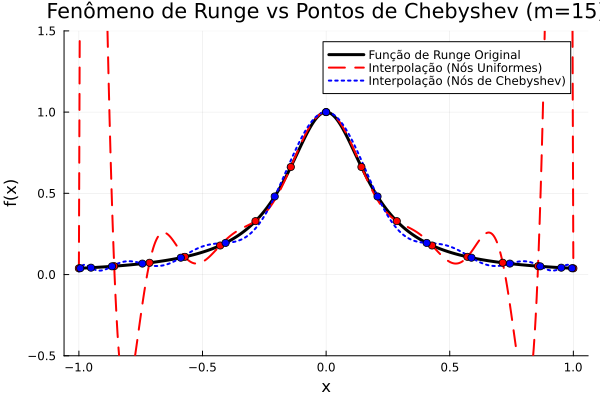

In [15]:
using Plots

# Função original (Função de Runge)
f(x) = 1.0 / (1.0 + 25.0 * x^2)

# Pontos de Chebyshev conforme definido na Questão 3(f)
function chebyshev_nodes(m)
    return [cos(((2i - 1) / (2m)) * π) for i in 1:m]
end

# Avaliação otimizada em O(md) usando a primeira forma baricêntrica
function barycentric_interpolate(nodes, f_nodes, x_eval)
    m = length(nodes)
    
    # 1. Pré-cálculo dos pesos baricêntricos: O(m^2)
    w = zeros(m)
    for j in 1:m
        w[j] = 1.0 / prod(nodes[j] - nodes[k] for k in 1:m if k != j)
    end
    
    # 2 e 3. Avaliação rápida para cada ponto x: O(m) por ponto
    y_eval = zeros(length(x_eval))
    for (i, x) in enumerate(x_eval)
        idx = findfirst(==(x), nodes)
        if !isnothing(idx)
            y_eval[i] = f_nodes[idx] # Evita divisão por zero se x for exatamente um nó
        else
            num = sum(w[j] * f_nodes[j] / (x - nodes[j]) for j in 1:m)
            den = sum(w[j] / (x - nodes[j]) for j in 1:m)
            y_eval[i] = num / den
        end
    end
    return y_eval
end

# ================= Execução do Teste ================= #

m = 15 # m pontos (equivale a um polinômio de grau d = 14)
x_dense = collect(range(-1.0, 1.0, length=500))
y_true = f.(x_dense)

# Caso 1: Nós Uniformemente Espaçados
nodes_uni = collect(range(-1.0, 1.0, length=m))
y_uni = barycentric_interpolate(nodes_uni, f.(nodes_uni), x_dense)

# Caso 2: Nós de Chebyshev
nodes_cheb = chebyshev_nodes(m)
y_cheb = barycentric_interpolate(nodes_cheb, f.(nodes_cheb), x_dense)

# Plotagem dos resultados
plt = plot(x_dense, y_true, label="Função de Runge Original", lw=3, color=:black)
plot!(plt, x_dense, y_uni, label="Interpolação (Nós Uniformes)", lw=2, ls=:dash, color=:red)
plot!(plt, x_dense, y_cheb, label="Interpolação (Nós de Chebyshev)", lw=2, ls=:dot, color=:blue)

scatter!(plt, nodes_uni, f.(nodes_uni), color=:red, label="", ms=4)
scatter!(plt, nodes_cheb, f.(nodes_cheb), color=:blue, label="", ms=4)

ylims!(plt, -0.5, 1.5)
title!(plt, "Fenômeno de Runge vs Pontos de Chebyshev (m=$m)")
xlabel!(plt, "x")
ylabel!(plt, "f(x)")

display(plt)